# Unemployment Analysis: Germany, France, Spain & Poland (1991–2021)

## Overview
This project explores unemployment trends in four major European economies 
over a 30-year period. Using data from Kaggle (World Bank), the analysis 
identifies key patterns, compares country trajectories, and links statistical 
findings to real economic events such as the 2008 financial crisis, 
EU enlargement, and the COVID-19 pandemic.

**Data source:** Kaggle — Unemployment Dataset (World Bank)  
**Tools:** Python, pandas, matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 33)
df = pd.read_csv('unemployment analysis.csv')

In [2]:
df.head()

,Country Name,Country Code,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Africa Eastern and Southern,AFE,7.80,7.84,7.85,7.84,7.83,7.84,7.86,7.81,7.79,7.72,7.73,7.96,7.79,7.31,7.12,6.99,6.74,6.27,6.32,6.87,6.75,6.56,6.45,6.41,6.49,6.61,6.71,6.73,6.91,7.56,8.11
1,Afghanistan,AFG,10.65,10.82,10.72,10.73,11.18,10.96,10.78,10.80,10.81,10.81,10.81,11.26,11.14,10.99,11.22,11.10,11.30,11.09,11.31,11.35,11.05,11.34,11.19,11.14,11.13,11.16,11.18,11.15,11.22,11.71,13.28
2,Africa Western and Central,AFW,4.42,4.53,4.55,4.54,4.53,4.57,4.60,4.66,4.86,4.92,4.87,4.78,4.75,4.73,4.73,4.65,4.63,4.60,4.58,4.55,4.55,4.64,4.41,4.69,4.63,5.57,6.02,6.04,6.06,6.77,6.84
3,Angola,AGO,4.21,4.21,4.23,4.16,4.11,4.10,4.09,4.07,4.05,4.03,4.00,3.96,3.96,3.92,3.88,3.86,3.82,3.79,3.78,9.43,7.36,7.35,7.37,7.37,7.39,7.41,7.41,7.42,7.42,8.33,8.53
4,Albania,ALB,10.31,30.01,25.26,20.84,14.61,13.93,16.88,20.05,20.84,19.03,18.58,17.90,16.99,16.31,15.97,15.63,15.97,13.06,13.67,14.09,13.48,13.38,15.87,18.05,17.19,15.42,13.62,12.30,11.47,13.33,11.82


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  235 non-null    str    
 1   Country Code  235 non-null    str    
 2   1991          235 non-null    float64
 3   1992          235 non-null    float64
 4   1993          235 non-null    float64
 5   1994          235 non-null    float64
 6   1995          235 non-null    float64
 7   1996          235 non-null    float64
 8   1997          235 non-null    float64
 9   1998          235 non-null    float64
 10  1999          235 non-null    float64
 11  2000          235 non-null    float64
 12  2001          235 non-null    float64
 13  2002          235 non-null    float64
 14  2003          235 non-null    float64
 15  2004          235 non-null    float64
 16  2005          235 non-null    float64
 17  2006          235 non-null    float64
 18  2007          235 non-null    float64
 19

In [4]:
germany = df[df['Country Name'] == 'Germany']

In [5]:
germany_long = germany.melt(value_vars=germany.columns[2:].to_list(), var_name='Year', value_name='Unemployment')

In [6]:
germany_long['Year'] = pd.to_numeric(germany_long['Year'])

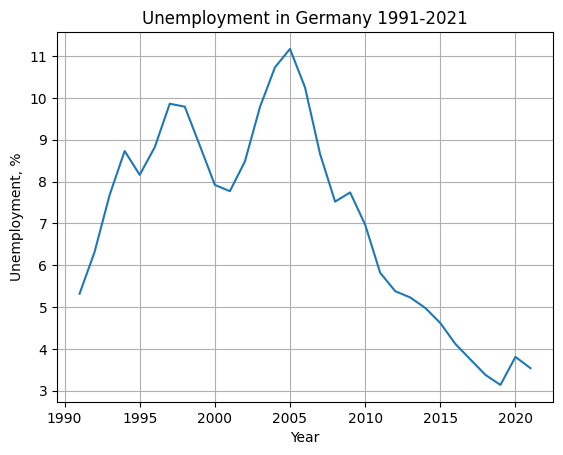

In [7]:
plt.plot(germany_long['Year'], germany_long['Unemployment'])
plt.xlabel('Year')
plt.ylabel('Unemployment, %')
plt.title('Unemployment in Germany 1991-2021')
plt.grid()
plt.show()

In [8]:
eu_countries = df[df['Country Name'].isin(['Germany', 'France', 'Spain', 'Poland'])]

In [9]:
eu_countries_long = eu_countries.melt(id_vars='Country Name', value_vars=eu_countries.columns[2:].to_list(), 
                                      var_name='Year', value_name='Unemployment')

In [10]:
eu_countries_long['Year'] = pd.to_numeric(eu_countries_long['Year'])

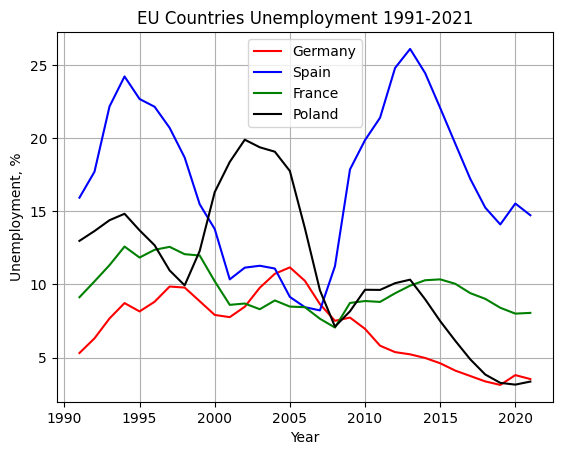

In [11]:
colors = ['red', 'blue', 'green', 'black']
unique_countries = eu_countries_long['Country Name'].unique()

for country_name, color in zip(unique_countries, colors):
    plt.plot(eu_countries_long[eu_countries_long['Country Name'] == country_name]['Year'], 
         eu_countries_long[eu_countries_long['Country Name'] == country_name]['Unemployment'], color=color, label=country_name)

plt.title('EU Countries Unemployment 1991-2021')
plt.xlabel('Year')
plt.ylabel('Unemployment, %')
plt.legend()
plt.grid()
plt.show()

This chart shows unemployment rates in Germany, France, Spain, and Poland from 1991 to 2021.    
Despite sharing similar long-term trends, the four countries differ significantly in the scale of unemployment. Spain stands out with peaks above 25% following the 2008 financial crisis, while Germany maintained the lowest and most stable rate throughout the period. Poland's sharp decline after 2004 coincides with its EU accession, which opened new labor markets and accelerated economic growth.

In [12]:
eu_countries_stats = eu_countries_long.groupby('Country Name')['Unemployment'].agg(['min', 'max', 'mean']).round({'mean':2})

This table shows the minimum, maximum, and mean unemployment rates in Germany, France, Spain, and Poland from 1991 to 2021. Germany leads with the lowest mean unemployment rate over this period. The mean unemployment in Germany is almost 10 percentage points lower than in Spain. At the same time, the maximum unemployment rate in Spain is more than twice that of Germany and France. Despite historically high peak levels, Poland's unemployment ultimately declined to a level comparable to Germany's.

In [13]:
unemployment_2021 = df[['Country Name', '2021']].sort_values('2021', ascending=False)
top_10_2021 = unemployment_2021.head(10)
top_10_2021

,Country Name,2021
232,South Africa,33.56
49,Djibouti,28.39
199,Eswatini,25.76
172,West Bank and Gaza,24.90
28,Botswana,24.72
123,Lesotho,24.60
39,"Congo, Rep.",23.01
70,Gabon,22.26
149,Namibia,21.68
224,St. Vincent and the Grenadines,21.62


This table shows the top 10 countries by unemployment rate in 2021. 
All ten countries are developing economies, predominantly from Africa, reflecting the structural challenges of labor markets in the region.

In [14]:
df_copy = df.copy()
df_copy['difference'] = df_copy['1991'] - df_copy['2021']
top_10_diff = df_copy.sort_values('difference', ascending=False).head(10)[['Country Name', 'difference']]
top_10_diff


,Country Name,difference
214,Trinidad and Tobago,13.72
25,Barbados,12.26
123,Lesotho,11.52
166,Poland,9.61
120,Sri Lanka,9.27
96,Ireland,9.15
100,Israel,8.34
136,North Macedonia,8.30
168,Puerto Rico,7.91
52,Algeria,7.90


This table shows the top 10 countries with the greatest reduction in unemployment between 1991 and 2021. 
Poland ranks 4th, which is consistent with the trend observed in the chart above — its EU accession in 2004 triggered a sustained decline in unemployment over the following decade.